# Train/Test Split and Baseline Models

This notebook compares baseline classification models across the screening, screening-plus-labs and full-clinical feature sets.


In [1]:
import pandas as pd

from pcosense.data import load_clean_data
from pcosense.features import FEATURE_SETS
from pcosense.preprocessing import create_train_test_split

In [2]:
data = load_clean_data()

print("Dataset shape:", data.shape)
print("Available feature sets:")

for name, features in FEATURE_SETS.items():
    print(f"- {name}: {len(features)} features")

Dataset shape: (541, 44)
Available feature sets:
- screening: 18 features
- screening_plus_labs: 28 features
- full_clinical: 33 features


In [3]:
splits = {}

for name, features in FEATURE_SETS.items():
    X_train, X_test, y_train, y_test = create_train_test_split(
        data=data,
        features=features,
        test_size=0.2,
        random_state=42,
    )

    splits[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
    }

    print(f"\n{name}")
    print("Training shape:", X_train.shape)
    print("Testing shape:", X_test.shape)
    print("Training labels:", y_train.value_counts().to_dict())
    print("Testing labels:", y_test.value_counts().to_dict())
    


screening
Training shape: (432, 18)
Testing shape: (109, 18)
Training labels: {0: 291, 1: 141}
Testing labels: {0: 73, 1: 36}

screening_plus_labs
Training shape: (432, 28)
Testing shape: (109, 28)
Training labels: {0: 291, 1: 141}
Testing labels: {0: 73, 1: 36}

full_clinical
Training shape: (432, 33)
Testing shape: (109, 33)
Training labels: {0: 291, 1: 141}
Testing labels: {0: 73, 1: 36}


## Baseline models

A Dummy Classifier provides a minimum benchmark by predicting according to the training-label distribution. Logistic Regression provides the first real interpretable model.

Preprocessing is fitted only on the training data to prevent test-data leakage.

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

from pcosense.preprocessing import build_numeric_preprocessor

In [5]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "f1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_test, probabilities),
        "pr_auc": average_precision_score(
            y_test, probabilities
        ),
    }

In [6]:
results = []
trained_models = {}

for feature_set, split in splits.items():
    models = {
        "dummy": Pipeline([
            (
                "preprocessor",
                build_numeric_preprocessor(scale=False)
            ),
            (
                "model",
                DummyClassifier(
                    strategy="prior",
                    random_state=42
                )
            ),
        ]),
        "logistic_regression": Pipeline([
            (
                "preprocessor",
                build_numeric_preprocessor(scale=True)
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            ),
        ]),
    }

    for model_name, model in models.items():
        model.fit(split["X_train"], split["y_train"])

        metrics = evaluate_model(
            model,
            split["X_test"],
            split["y_test"]
        )

        results.append({
            "feature_set": feature_set,
            "model": model_name,
            **metrics,
        })

        trained_models[(feature_set, model_name)] = model

In [7]:
results_df = pd.DataFrame(results)

metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
]

results_df[metric_columns] = (
    results_df[metric_columns].round(3)
)

display(
    results_df.sort_values(
        ["model", "roc_auc"],
        ascending=[True, False]
    )
)

,feature_set,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,screening,dummy,0.670,0.000,0.000,0.000,0.500,0.330
2,screening_plus_labs,dummy,0.670,0.000,0.000,0.000,0.500,0.330
4,full_clinical,dummy,0.670,0.000,0.000,0.000,0.500,0.330
5,full_clinical,logistic_regression,0.881,0.795,0.861,0.827,0.946,0.934
1,screening,logistic_regression,0.835,0.725,0.806,0.763,0.884,0.801
3,screening_plus_labs,logistic_regression,0.798,0.667,0.778,0.718,0.884,0.768


### Initial baseline interpretation

- The Dummy Classifier achieves 67% accuracy by predicting only the majority class, but its recall and F1 score are zero.
- The screening Logistic Regression substantially outperforms the dummy baseline.
- Adding laboratory features does not improve performance on this test split.
- The full clinical model performs best, with an ROC-AUC of 0.946.
- The improvement from clinical features may be influenced by ultrasound-related diagnostic leakage.
- A single train/test split is not sufficient for final model selection, so stratified cross-validation is required.

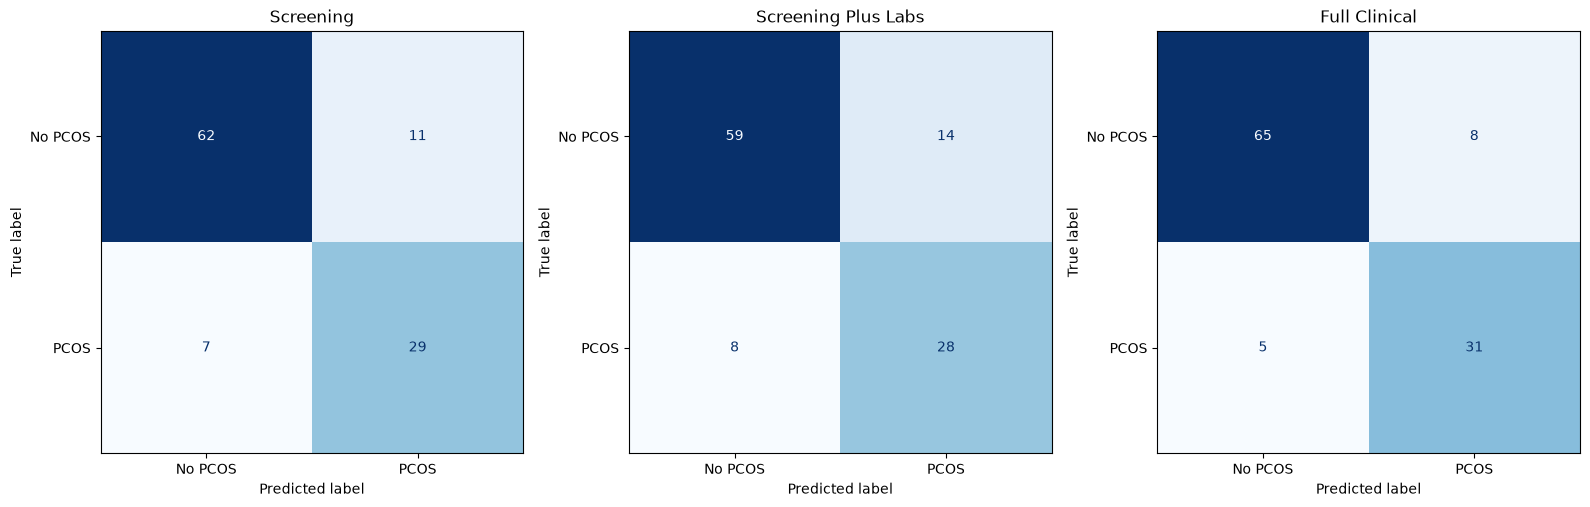

In [8]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for axis, feature_set in zip(axes, FEATURE_SETS):
    split = splits[feature_set]
    model = trained_models[
        (feature_set, "logistic_regression")
    ]

    ConfusionMatrixDisplay.from_estimator(
        model,
        split["X_test"],
        split["y_test"],
        display_labels=["No PCOS", "PCOS"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )

    axis.set_title(feature_set.replace("_", " ").title())

plt.tight_layout()
plt.show()


In [9]:
import numpy as np

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

In [10]:
cv_results = []

for feature_set, features in FEATURE_SETS.items():
    X = data[features]
    y = data["PCOS (Y/N)"]

    model = Pipeline([
        (
            "preprocessor",
            build_numeric_preprocessor(scale=True)
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ])

    scores = cross_validate(
        model,
        X,
        y,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1,
    )

    result = {"feature_set": feature_set}

    for metric in scoring:
        result[f"{metric}_mean"] = np.mean(
            scores[f"test_{metric}"]
        )
        result[f"{metric}_std"] = np.std(
            scores[f"test_{metric}"]
        )

    cv_results.append(result)

In [11]:
cv_results_df = pd.DataFrame(cv_results)

numeric_columns = cv_results_df.select_dtypes(
    include="number"
).columns

cv_results_df[numeric_columns] = (
    cv_results_df[numeric_columns].round(3)
)

display(cv_results_df)

,feature_set,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,screening,0.823,0.026,0.702,0.048,0.808,0.031,0.750,0.028,0.880,0.029,0.814,0.071
1,screening_plus_labs,0.810,0.034,0.687,0.056,0.780,0.053,0.729,0.042,0.869,0.035,0.803,0.064
2,full_clinical,0.883,0.027,0.792,0.060,0.882,0.027,0.833,0.034,0.945,0.008,0.918,0.005
